<a href="https://colab.research.google.com/github/2023giteshpeswani/MLDL-EXPS/blob/main/MLDLexp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [ ]:
path = kagglehub.dataset_download("osmi/mental-health-in-tech-survey")

print("Files inside folder:", os.listdir(path))

df = pd.read_csv(path + "/survey.csv")  # file name list se confirm karo
df.head()

Using Colab cache for faster access to the 'mental-health-in-tech-survey' dataset.
Files inside folder: ['survey.csv']


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [ ]:
df.drop(['Timestamp','comments','state'], axis=1, inplace=True, errors='ignore')
df.ffill(inplace=True)

In [ ]:
order_map = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3
}
df['work_interfere'] = df['work_interfere'].map(order_map)

# Remove rows where mapping failed
df = df.dropna(subset=['work_interfere'])

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])

In [ ]:
X = df.drop('work_interfere', axis=1)
y = df['work_interfere']



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=300)
model.fit(X_train, y_train)


LogisticRegression(max_iter=300)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Mean Squared Error: 1.2936507936507937
R2 Score: -0.2895286232282168


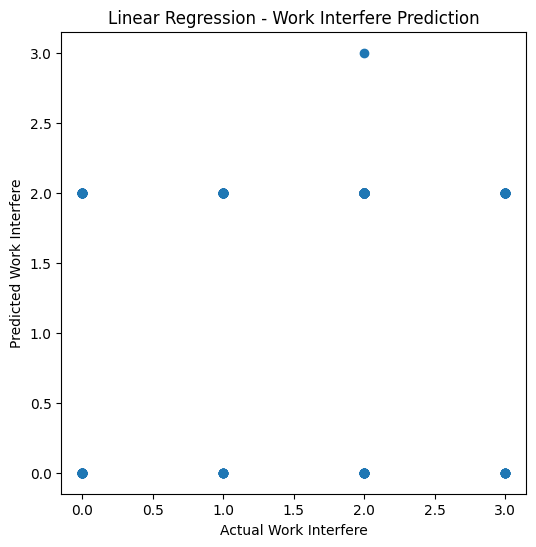

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test.values, y_pred)
plt.xlabel("Actual Work Interfere")
plt.ylabel("Predicted Work Interfere")
plt.title("Linear Regression - Work Interfere Prediction")
plt.show()

In [ ]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df = df[(df['Age'] > 15) & (df['Age'] < 70)]

# Fill missing
df.ffill(inplace=True)

In [ ]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


In [ ]:
X = df.drop('treatment', axis=1)   # Features
y = df['treatment']                # Target (Yes/No)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=300)
model.fit(X_train, y_train)

LogisticRegression(max_iter=300)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.736

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.79      0.73       115
           1       0.79      0.69      0.74       135

    accuracy                           0.74       250
   macro avg       0.74      0.74      0.74       250
weighted avg       0.74      0.74      0.74       250



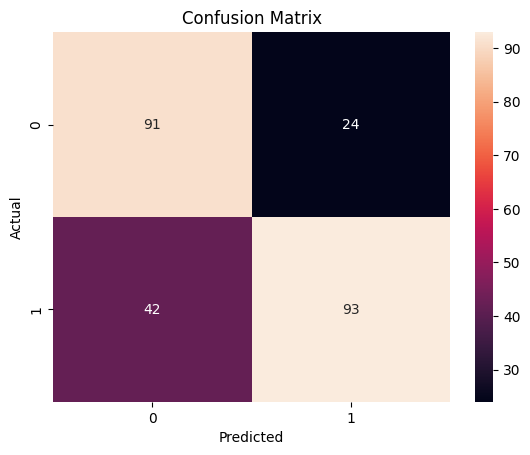

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()